### Uygulama: Diabetes (Diyabet) Veri Seti
* Kaynak: sklearn.datasets.load_diabetes()
* Örnek sayısı: 442 hasta
* Özellik sayısı: 10 sayısal özellik
* Hedef (target): Hastanın 1 yıl sonraki hastalık ilerleme ölçüsü (sürekli bir
değer).
* Amaç: Hastaya ait ölçümlere bakarak hastalığın ne kadar ilerleyeceğini
matematiksel olarak tahmin etmek.
* bmi: Vücut kitle indeksi
* bp: Kan basıncı
* s1-s6: Çeşitli kan testleri sonuçları
Regresyon problemi — Bir sayısal değer tahmin edilecek.

In [1]:
from sklearn. datasets import load_diabetes
diabetes = load_diabetes ()
X = diabetes .data
y = diabetes .target
print(X.shape) # Cikti: (442 , 10)
print(diabetes . feature_names )

(442, 10)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


### Özellik Hedef İlişkisi

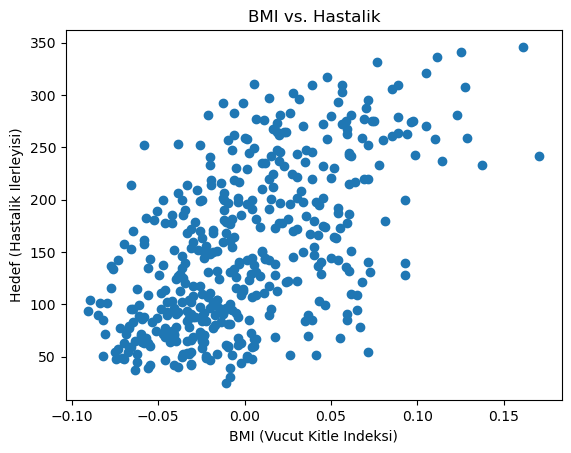

In [7]:
import matplotlib .pyplot as plt
# 2. indeks olan BMI sutununu aliyoruz

plt.scatter(X[:, 2], y)
plt.xlabel("BMI (Vucut Kitle Indeksi)")
plt.ylabel("Hedef (Hastalik Ilerleyisi)")
plt.title("BMI vs. Hastalik")
plt.show ()


### Regresyon Modeli Eğitimi

In [8]:
from sklearn. linear_model import LinearRegression
from sklearn. model_selection import train_test_split

# Egitim (%80) ve Test (%20) bolunmesi
X_train , X_test , y_train , y_test = train_test_split (
X, y, test_size =0.2 , random_state =42)

# Modeli olustur ve egit
model = LinearRegression ()
model.fit(X_train , y_train)

LinearRegression()

### Model Başarısının Hesaplanması

In [9]:
from sklearn.metrics import mean_squared_error ,mean_absolute_error , r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error (y_test , y_pred)
mae = mean_absolute_error (y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R^2 Skoru:", r2)

Mean Squared Error (MSE): 2900.1936284934804
Mean Absolute Error (MAE): 42.79409467959994
R^2 Skoru: 0.4526027629719196


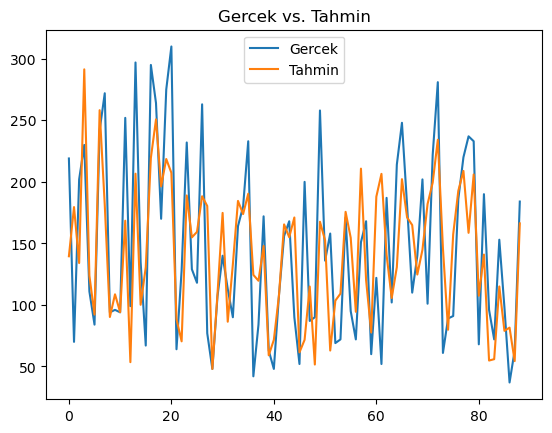

In [14]:
plt.plot(y_test , label="Gercek")
plt.plot(y_pred , label="Tahmin")
plt.legend ()
plt.title("Gercek vs. Tahmin")
plt.show ()

### İyileştirme: Diabetes (Diyabet) Veri Seti

X shape: (442, 10)
Özellik isimleri: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


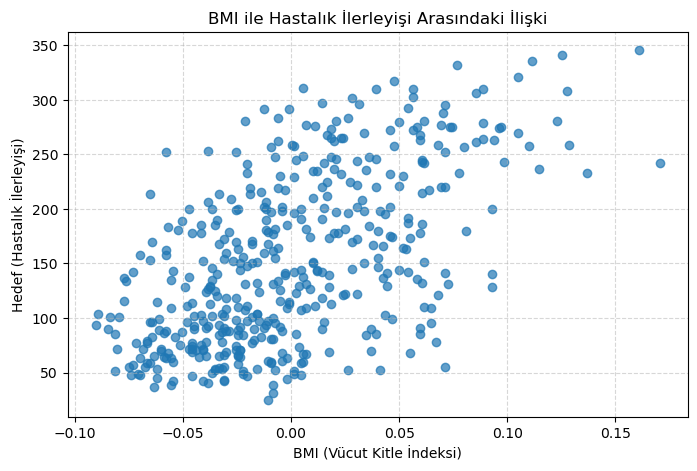

Eğitim veri boyutu: (353, 10)
Test veri boyutu: (89, 10)
Mean Squared Error (MSE): 2900.19
Root Mean Squared Error (RMSE): 53.85
Mean Absolute Error (MAE): 42.79
R^2 Skoru: 45.26


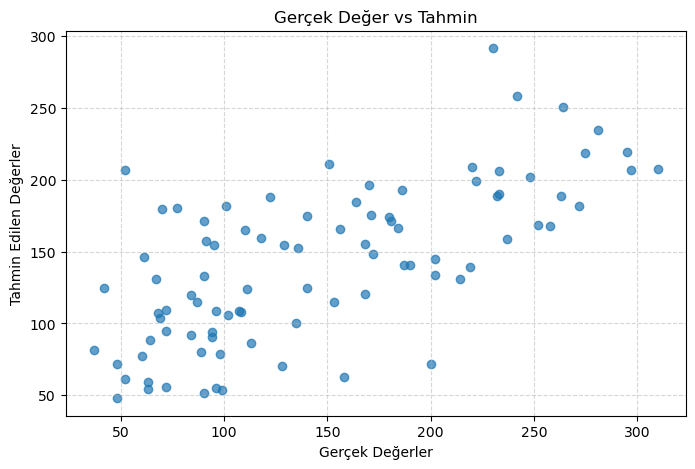

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


# 1) Veri setini yükle
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

print("X shape:", X.shape)              # (442, 10)
print("Özellik isimleri:", feature_names)


# 2) BMI sütununu görselleştir
bmi_index = feature_names.index("bmi")

plt.figure(figsize=(8, 5))
plt.scatter(X[:, bmi_index], y, alpha=0.7)
plt.xlabel("BMI (Vücut Kitle İndeksi)")
plt.ylabel("Hedef (Hastalık İlerleyişi)")
plt.title("BMI ile Hastalık İlerleyişi Arasındaki İlişki")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# 3) Eğitim-test bölmesi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)


# 4) Model oluşturma ve eğitme
model = LinearRegression()
model.fit(X_train, y_train)


# 5) Tahmin yapma
y_pred = model.predict(X_test)


# 6) Performans metrikleri
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R^2 Skoru: {r2*100:.2f}")


# 7) Gerçek ve tahmin karşılaştırması
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")
plt.title("Gerçek Değer vs Tahmin")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

<b>Mean Absolute Percentage Error</b>

In [12]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAPE: %{mape*100:.2f}")

MAPE: %37.50


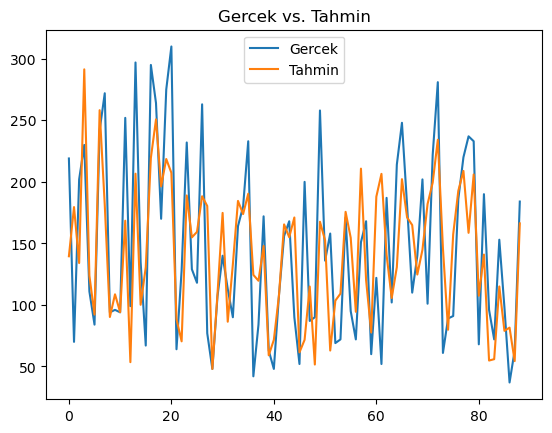

In [13]:
plt.plot(y_test , label="Gercek")
plt.plot(y_pred , label="Tahmin")
plt.legend ()
plt.title("Gercek vs. Tahmin")
plt.show ()

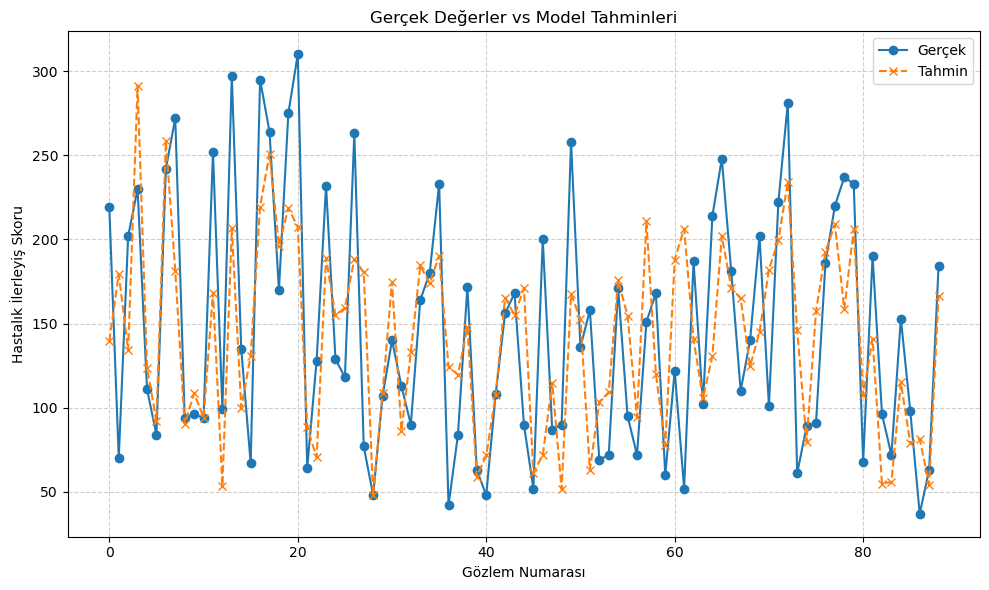

In [15]:
plt.figure(figsize=(10,6))

# Gerçek değerler
plt.plot(y_test.values if hasattr(y_test,"values") else y_test,
         marker='o',
         linestyle='-',
         label="Gerçek")

# Tahmin değerleri
plt.plot(y_pred,
         marker='x',
         linestyle='--',
         label="Tahmin")

plt.title("Gerçek Değerler vs Model Tahminleri")
plt.xlabel("Gözlem Numarası")
plt.ylabel("Hastalık İlerleyiş Skoru")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

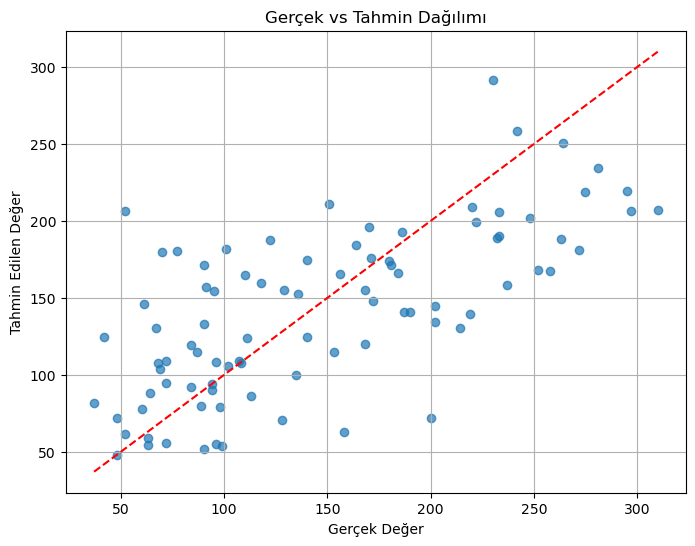

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin Edilen Değer")
plt.title("Gerçek vs Tahmin Dağılımı")

plt.grid(True)

plt.show()

### Uygulama: Iris Veri Seti ile Kümeleme

In [17]:
from sklearn. datasets import load_iris
iris = load_iris ()
X = iris.data
y_true = iris.target
feature_names = iris. feature_names


* 3 sınıflı (farklı çiçek türü), 4 özellikli etiketlenmiş veri.
* X: Kümeleme algoritmalarına giriş olarak verilecek.
* y_true: son aşamada değerlendirme için kullanılacak

### KMeans ile Kümeleme

In [22]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

# n_clusters=3 cunku 3 cicek turu oldugunu biliyoruz
kmeans = KMeans( n_clusters =3, random_state =0)
labels_kmeans = kmeans.fit_predict(X)


### DBSCAN ile Kümeleme

In [24]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps =0.6 , min_samples =4)
labels_dbscan = dbscan. fit_predict (X)

* Yoğunluk temelli: Küme sayısı önceden verilmez.
* eps (yarıçap) ve min_samples (minimum nokta) parametreleri kritik rol oynar

### Hiyerarşik Kümeleme (Agglomerative)

In [27]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering( n_clusters =3)
labels_agg = agg.fit_predict(X)

In [28]:
from sklearn. decomposition import PCA
pca = PCA( n_components =2)
X_pca = pca. fit_transform (X)

* PCA gözetimsiz bir boyut indirgeme algoritmasıdır.
* Kümeleme sonuçlarını görsel olarak 2D düzlemde karşılaştırmaktır

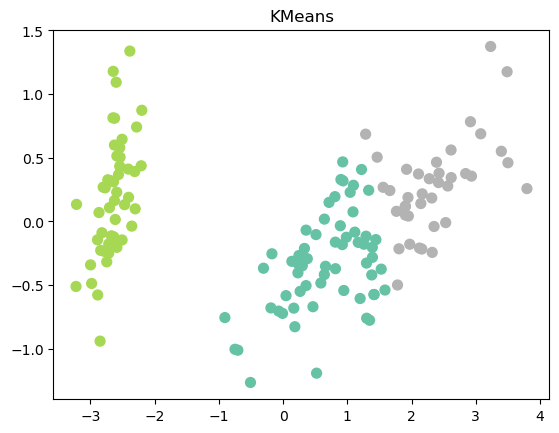

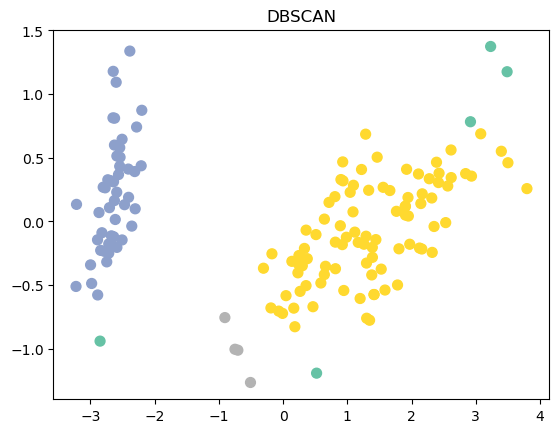

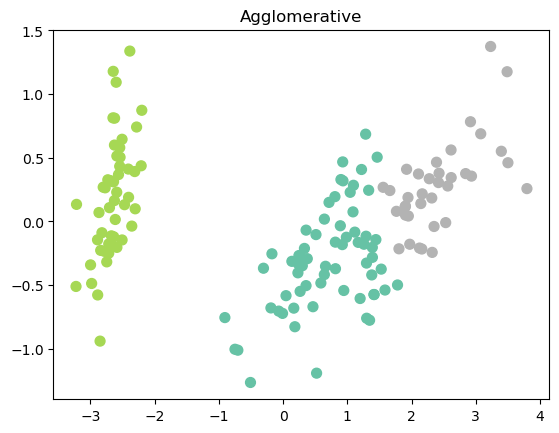

In [31]:
def plot_clusters (title , labels):
    plt.scatter(X_pca [:, 0], X_pca [:, 1], c=labels , cmap="Set2",s=50)
    plt.title(title)
    plt.show ()
plot_clusters ("KMeans", labels_kmeans )
plot_clusters ("DBSCAN", labels_dbscan )
plot_clusters ("Agglomerative", labels_agg )

#### Yorum ve Uygunluk
* KMeans: Küme sayısı biliniyorsa başarılı.
* DBSCAN: Gürültülü, dağınık ve iç içe geçmiş verilerde avantajlı.
* Agglomerative: Küme yapısı belirsizken dendrogram ile ağaç yapısını
görmek istendiğinde iyi çalışır.

### Veri Seti: Breast Cancer
* Amaç: Hastadan alınan hücre özelliklerine bakarak tümörün iyi huylu
(benign) ya da kötü huylu (malignant) olup olmadığını tahmin etmek.
* Özellik sayısı: 30 (Örnek: hücre yarıçapı, dokusu, çevresi vs.)
* Sınıf sayısı: 2 (Benign = İyi Huylu, Malignant = Kötü Huylu)
* Kullanılan kütüphane: sklearn.datasets.load_breast_cancer

In [33]:
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix

<b>Sınıflandırma Algoritmaları</b>

In [46]:
from sklearn. linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

<b>Veri Seti Hazırlığı ve Veri Sızıntısı (Data Leakage) Önlemi</b>

In [47]:
data = load_breast_cancer ()
X = data.data
y = data.target

X_train , X_test , y_train , y_test = train_test_split (X, y,test_size =0.2,stratify=y,random_state =42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<b>Modellerin Tanımlanması</b>

In [48]:
models = {
    "Lojistik Regresyon": LogisticRegression(max_iter =1000),
    "Karar Agaci": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "K-En Yakin Komsu": KNeighborsClassifier()
}

<b>Model Eğitimi ve Değerlendirme</b>

In [49]:
results = []
for name , model in models.items ():
    model.fit(X_train_scaled , y_train)
    y_pred = model.predict( X_test_scaled )
    acc = accuracy_score (y_test , y_pred)
    results.append ((name , acc))

<b>Değerlendirme</b>

                Model  Dogruluk Skoru
0  Lojistik Regresyon        0.982456
3                 SVM        0.982456
2       Random Forest        0.956140
4    K-En Yakin Komsu        0.956140
1         Karar Agaci        0.912281


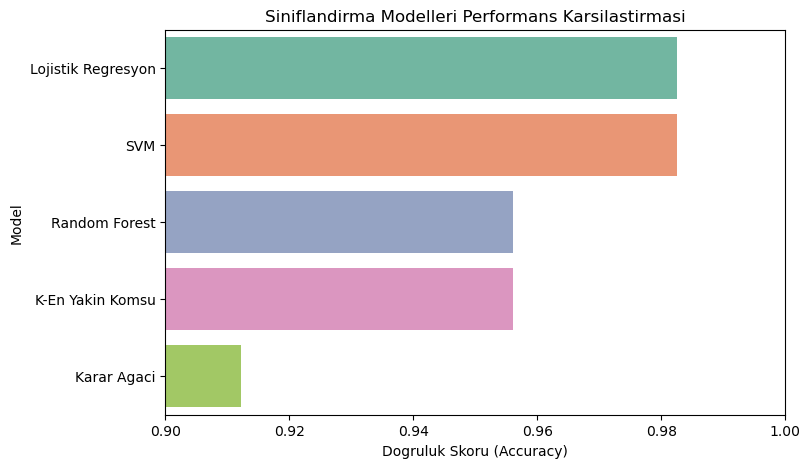

In [50]:
results_df = pd. DataFrame (results , columns =["Model", "Dogruluk Skoru"])
results_df = results_df . sort_values (by="Dogruluk Skoru",ascending =False)

print( results_df )

plt.figure(figsize =(8 ,5))
sns.barplot(x="Dogruluk Skoru", y="Model", data=results_df ,palette="Set2")
plt.title("Siniflandirma Modelleri Performans Karsilastirmasi")
plt.xlabel("Dogruluk Skoru (Accuracy)")
plt.xlim(0.9 , 1.0)
plt.show()